## Parte 4 

In [10]:
import numpy as np
from PIL import Image
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay 
from scipy.optimize import linear_sum_assignment
import os # Para leer todos los ficheros de la misma carpeta y no hacerlo a mano
import networkx as nx
from gensim.models import Word2Vec # Para hacer el node2vec

def load_and_preprocess_images2():
    """
    Carga y preprocesa pares de imágenes y sus keypoints
    """
    # Definimos tamaño objeto
    obj_resize = (256,256)
    category = 'Duck'
    ruta = './data/WillowObject/WILLOW-ObjectClass/' + category
    #Definimos las listas donde vamos a guardar los distintos elementos
    pngs = []
    mats = []
    imgs = []
    kpts_list = []
    # Recorremos directorio indicado
    # Guardamos los archivos png y mat en dos listas separadas (pero ordenadas)
    for img in os.listdir(ruta):
        if img.endswith('.png'):
            pngs.append(img)
        elif img.endswith('.mat'):
            mats.append(img)
    pngs = sorted(pngs)
    mats = sorted(mats)
    # Ya tenemos los pngs y mats guardados en listas
    for i in range(8):
        img = Image.open(ruta + '/' + pngs[i])
        kpts = np.array(sio.loadmat(ruta + '/' + mats[i])['pts_coord'])
        kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
        kpts[1] = kpts[1] * obj_resize[1] / img.size[1]
        img = img.resize(obj_resize, resample=Image.BILINEAR)
        kpts_list.append(kpts)
        imgs.append(img)
    # Devolvemos los valores para poder usar la otra función

        # Definimos tamaño objeto
    obj_resize = (256,256)
    category = 'Duck'
    ruta = './data/WillowObject/WILLOW-ObjectClass/' + category
    #Definimos las listas donde vamos a guardar los distintos elementos
    pngs = []
    mats = []
    imgs2 = []
    kpts_list2 = []
    # Recorremos directorio indicado
    # Guardamos los archivos png y mat en dos listas separadas (pero ordenadas)
    for img in os.listdir(ruta):
        if img.endswith('.png'):
            pngs.append(img)
        elif img.endswith('.mat'):
            mats.append(img)
    pngs = sorted(pngs)
    mats = sorted(mats)
    # Ya tenemos los pngs y mats guardados en listas
    for i in range(8):
        img = Image.open(ruta + '/' + pngs[i])
        kpts = np.array(sio.loadmat(ruta + '/' + mats[i])['pts_coord'])
        kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
        kpts[1] = kpts[1] * obj_resize[1] / img.size[1]
        img = img.resize(obj_resize, resample=Image.BILINEAR)
        kpts_list2.append(kpts)
        imgs2.append(img)

    return imgs[0], imgs2[1], kpts_list[0], kpts_list2[1]


def delaunay_triangulation(kpts):
    """
    Generate adjacency matrix based on Delaunay triangulation
    """
    pts = kpts.T
    tri = Delaunay(pts)
    N = pts.shape[0]
    A = np.zeros((N, N), dtype=int)

    for simplex in tri.simplices:
        a, b, c = simplex
        # Poner 1 en la matriz para cada arista
        A[a, b] = 1
        A[b, a] = 1
        A[b, c] = 1
        A[c, b] = 1
        A[a, c] = 1
        A[c, a] = 1

    return A

# Función para realizar una caminata aleatoria en el grafo
def node2vec_walk(G, start_node, walk_length):
    walk = [start_node]
    while len(walk) < walk_length:
        cur_node = walk[-1]
        neighbors = list(G.neighbors(cur_node))
        if len(neighbors) > 0:
            walk.append(np.random.choice(neighbors))  # Selecciona un vecino al azar
        else:
            break
    return walk

# Función para generar múltiples caminatas aleatorias desde cada nodo del grafo
def generate_walks(G, num_walks, walk_length):
    walks = []
    nodes = list(G.nodes())
    for _ in range(num_walks):
        np.random.shuffle(nodes)  # Mezcla los nodos para añadir aleatoriedad
        for node in nodes:
            walks.append(node2vec_walk(G, node, walk_length))  # Genera una caminata aleatoria desde el nodo
    return walks


def compute_node2vec_embeddings(G, dimensions=64, num_walks=10, walk_length=30):
    """
    Compute node2vec embeddings for the graph
    """
    walks = generate_walks(G, num_walks, walk_length)  # Genera todas las caminatas aleatorias
    walks = [list(map(str, walk)) for walk in walks]  # Convierte los nodos a cadenas para gensim
    # walks: Lista de caminatas aleatorias
    # vector_size=dimensions: Tamaño del vector de embeddings
    # window=5: Tamaño de la ventana de contexto, en nodos seria 5 nodos a la izquierda y 5 nodos a la derecha
    # workers=2: Número de hilos para entrenar el modelo
    model = Word2Vec(walks, vector_size=dimensions, window=5, workers=2)  # Entrena el modelo Word2Vec con las caminatas aleatorias
    node_id = 0
    embedding = model.wv[str(node_id)]
    
    
    return embedding

def enhanced_spatial_matching(kpts1, kpts2, adj_matrix1, adj_matrix2):
    """
    Perform enhanced matching using spatial, hitting time, and node2vec features
 

    
    Args:
        kpts1: Array de keypoints del primer grafo (2xN)
        kpts2: Array de keypoints del segundo grafo (2xN)
        adj_matrix1: Matriz de adyacencia del primer grafo (NxN)
        adj_matrix2: Matriz de adyacencia del segundo grafo (NxN)
    
    Returns:
        matching: Matriz binaria donde matching[i,j]=1 indica correspondencia entre puntos
    Hints:
        - Primero deberás crear una matriz de costes basada en distancias euclidianas,
        cuyo tamaño será (n1, n2) donde n1 y n2 son el número de keypoints en cada grafo.
        - Seguidamente, deberás rellenar dicha matriz con las distancias euclidianas de los keypoints, las distancias/normas de node2vec 
        - A continuación, deberás aplicar el algoritmo húngaro usando la función linear_sum_assignment, que recibe la matriz de costes y devuelve los índices de los puntos emparejados.
        - Finalmente, deberás crear una matriz de matching a partir de los índices obtenidos.

    """
    # Create graphs
    n1, n2 = kpts1.shape[1], kpts2.shape[1]
    G1 = nx.from_numpy_array(adj_matrix1)
    G2 = nx.from_numpy_array(adj_matrix2)
    print("Computing node2vec embeddings...")
    node2vec_emb1 = compute_node2vec_embeddings(G1)
    node2vec_emb2 = compute_node2vec_embeddings(G2)
    
    # Create cost matrix combining different features
    cost_matrix = np.zeros((n1, n2))
    
    for i in range(n1):
        for j in range(n2):
            # Spatial distance
            spatial_dist = np.sqrt(np.sum((kpts1[:,i] - kpts2[:,j])**2))
            
            # Node2vec similarity
            node2vec_dist = np.sqrt(np.sum((node2vec_emb1[i] - node2vec_emb2[j])**2))
            
            # Combine distances with weights
            cost_matrix[i,j] = (
                0.6 * spatial_dist +
                0.4 * node2vec_dist
            )
            
    row_index,col_index = linear_sum_assignment(cost_matrix)
    # Pasamos de un array de 2XE a un array de NxN
    matching = np.zeros((n1,n2))
    matching[row_index,col_index] = 1
    
    return matching

def visualize_matching_full(img1, img2, kpts1, kpts2, adj_matrix1, adj_matrix2, matching):
    """
    Visualiza el matching completo entre dos grafos
    """
    
    
    # Graficar una imagen al lado de otra
    plt.figure(figsize=(15,8))
    # SI ya estan redimensionadas no haria falta (el max), simplemente se haria ancho = img1.shape
    ancho = max (img1.size[0],img2.size[0])
    alto = max (img1.size[1],img2.size[1])
    composicion = Image.new('RGB', (ancho*2, alto))
    composicion.paste(img1, (0,0))
    composicion.paste(img2, (ancho,0))
    plt.imshow(composicion)
    
    
    # Graficar las coordenadas (keypoints)
    plt.scatter(kpts1[0], kpts1[1], c='w', edgecolors='k', s=100)
    plt.scatter(kpts2[0] + ancho, kpts2[1], c='w', edgecolors='k', s=100)
    # Graficamoslas arsitas del matching
    matching = np.array(matching)
    for i in range(matching.shape[0]):
        for j in range(matching.shape[1]):
            if matching[i,j] > 0:
                color = 'g' if i==j else 'r'
                plt.plot([kpts1[0,i], kpts2[0,j] + ancho],
                         [kpts1[1,i], kpts2[1,j]],
                         color = color, linewidth=2)

## Exercise 2

Computing node2vec embeddings...


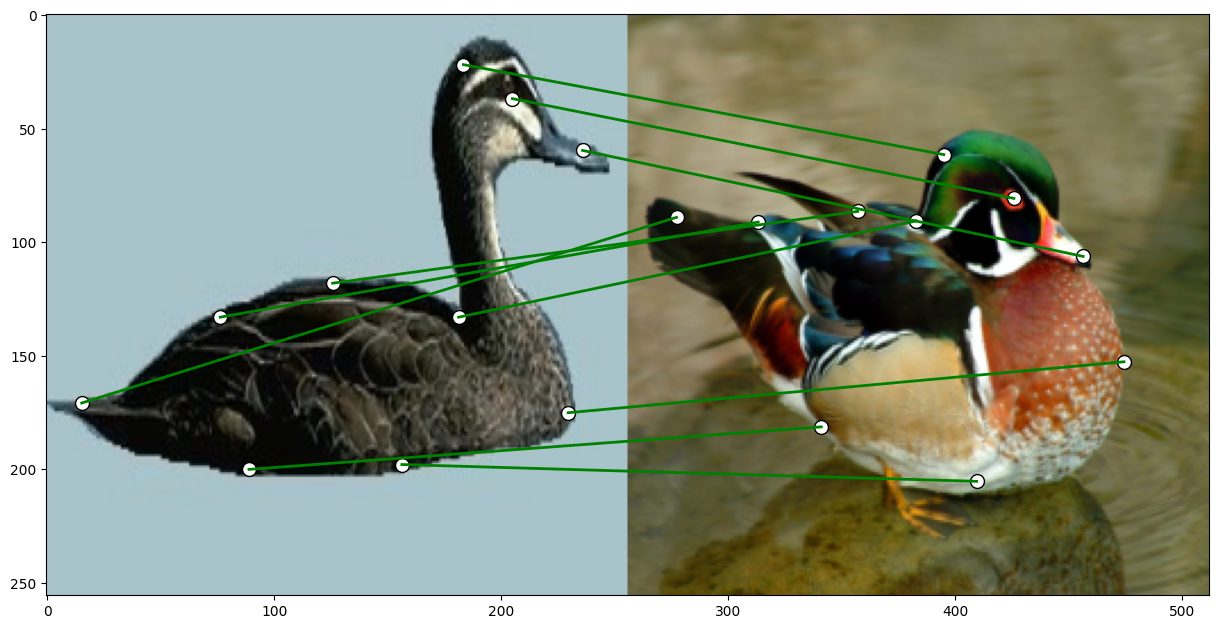

In [11]:
#Cargamos las dos imágenes
imgs1,imgs2,kpts1,kpts2 = load_and_preprocess_images2()

#Matriz de adyacencia
A = delaunay_triangulation(kpts1)
A2 = delaunay_triangulation(kpts2)

#Matching
matching = enhanced_spatial_matching(kpts1,kpts2,adj_matrix1=A,adj_matrix2=A2)

#Visualizamos las imágenes
visualize_matching_full(imgs1,imgs2,kpts1,kpts2,A,A2,matching)